# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студенты гр. 2383 Борисов Иван Павлович, Иваницкий Илья Александрович. Вариант №26

## Цель работы
Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Основные теоретические положения


**Метод наименьших квадратов (МНК)**

Пусть дана выборка $(x_i, y_i), \; i = 1, \dots, n$. Линейная регрессионная модель имеет вид:
$$
y = \beta_0 + \beta_1 x + \varepsilon,
$$
где $\varepsilon$ — случайная ошибка.

Оценки параметров $\beta_0, \beta_1$ находятся методом наименьших квадратов из условия минимизации:
$$
\sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2 \to \min.
$$

Отсюда получаем:
$$
\hat{\beta}_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \quad
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}.
$$

**Выборочные прямые регрессии**

Прямая регрессии $Y$ на $X$:
$$
\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x.
$$
Прямая регрессии $X$ на $Y$:
$$
\hat{x} = \tilde{\beta}_0 + \tilde{\beta}_1 y,
$$
где
$$
\tilde{\beta}_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (y_i - \bar{y})^2}, \quad
\tilde{\beta}_0 = \bar{x} - \tilde{\beta}_1 \bar{y}.
$$

**Коэффициент корреляции**

Выборочный коэффициент корреляции Пирсона:
$$
r_{xy} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}, \quad -1 \le r_{xy} \le 1.
$$

**Корреляционное отношение**

Корреляционное отношение (для зависимости $Y$ от $X$):
$$
\eta^2_{yx} = \frac{\sum n_j (\bar{y}_j - \bar{y})^2}{\sum (y_i - \bar{y})^2},
$$
где $\bar{y}_j$ — условные средние.

Свойство:
$$
\eta_{yx} \ge |r_{xy}|.
$$

**Нелинейные регрессионные модели**

Параболическая модель:
$$
y = \beta_0 + \beta_1 x + \beta_2 x^2.
$$

Дробно-линейная модель:
$$
y = \frac{1}{\beta_0 + \beta_1 x}.
$$

**Показатели качества регрессии**

Коэффициент детерминации:
$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}.
$$

Среднеквадратическая ошибка:
$$
S_\varepsilon = \sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}.
$$

Средняя ошибка аппроксимации:
$$
A = \frac{1}{n} \sum \left| \frac{y_i - \hat{y}_i}{y_i} \right| \cdot 100\%.
$$

## Постановка задачи
Для заданной двумерной выборки (X,Y) построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

### **1.** Отобразить двумерную выборку на графике.

In [24]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

data = pd.read_csv("data.csv")
data.head()

,alcohol,density
0,9.4,0.9978
1,9.8,0.9968
2,9.8,0.9970
3,9.8,0.9980
4,9.4,0.9978


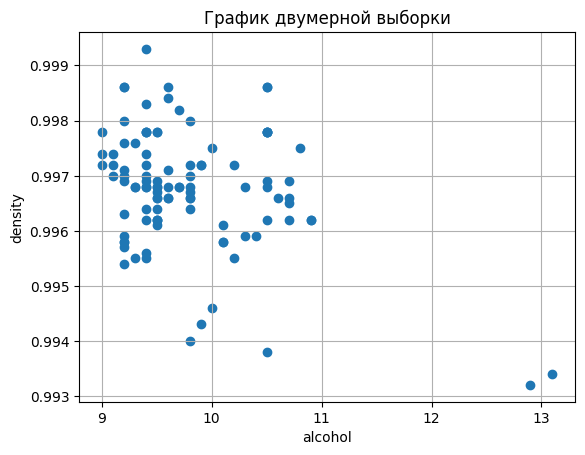

In [25]:
import matplotlib.pyplot as plt

alc_data = data["alcohol"]
den_data = data["density"]

# построение диаграммы рассеяния
plt.scatter(alc_data, den_data)
plt.xlabel('alcohol')
plt.ylabel('density')
plt.title('График двумерной выборки')
plt.grid()
plt.show()

### **2.** Для заданной выборки построить уравнения средней квадратичной регрессии x на y и y на x соответственно. Построить полученные прямые на множестве выборки. Объяснить результаты.

In [28]:
# Y на X
mean_x = np.mean(alc_data)
mean_y = np.mean(den_data)

cov_xy = np.mean((alc_data - mean_x)*(den_data - mean_y))
var_x = np.mean((alc_data - mean_x)**2)

a_yx = cov_xy / var_x
b_yx = mean_y - a_yx * mean_x

# X на Y
var_y = np.mean((den_data - mean_y)**2)

a_xy = cov_xy / var_y
b_xy = mean_x - a_xy * mean_y

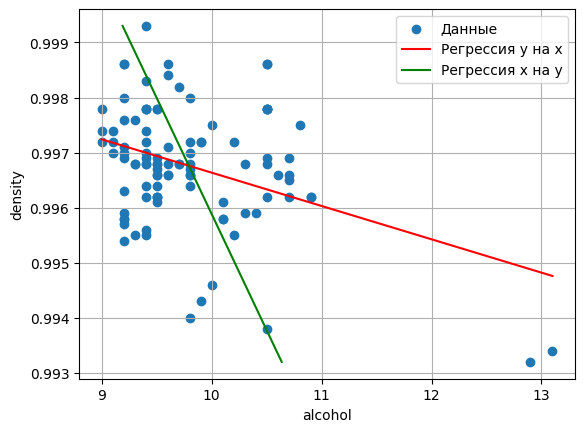

In [29]:
plt.scatter(alc_data, den_data, label='Данные')
plt.xlabel('alcohol')
plt.ylabel('density')

# линия y на x
x_vals = np.linspace(min(alc_data), max(alc_data), 100)
y_vals = a_yx * x_vals + b_yx
plt.plot(x_vals, y_vals, color='red', label='Регрессия y на x')

# линия x на y
y_vals2 = np.linspace(min(den_data), max(den_data), 100)
x_vals2 = a_xy * y_vals2 + b_xy
plt.plot(x_vals2, y_vals2, color='green', label='Регрессия x на y')

plt.legend()
plt.grid()
plt.show()

Наблюдается **слабая отрицательная линейная зависимость** между `alcohol` и `density`.

Прямые регрессии $y(x)$ и $x(y)$ различаются, так как минимизируют ошибки по разным переменным.

Значительный разброс точек указывает на **низкую точность линейной модели**.

### **3.** Составить корреляционную таблицу для нахождения выборочного корреляционного отношения. Убедиться, что неравенства $\eta_{xy} \geq |r_{xy}|$ и $\eta_{yx} \geq |r_{xy}|$ выполняются.

In [30]:
import pandas as pd
import numpy as np

X = data['alcohol'].values
Y = data['density'].values
n = len(X)

# Определяем количество интервалов
k = int(np.ceil(1 + 3.322 * np.log10(n)))

# Строим интервалы
bins_x = np.linspace(X.min(), X.max(), k + 1)
bins_y = np.linspace(Y.min(), Y.max(), k + 1)

# Вычисляем середины интервалов
mid_x = np.array([(bins_x[i] + bins_x[i+1]) / 2 for i in range(k)])
mid_y = np.array([(bins_y[j] + bins_y[j+1]) / 2 for j in range(k)])

# Строим двумерную гистограмму
H, xedges, yedges = np.histogram2d(X, Y, bins=[bins_x, bins_y])
H = H.astype(int)

# Создаем подписи для строк и столбцов (используем середины интервалов)
row_labels = [f'{mid_x[i]:.3f}' for i in range(k)]
col_labels = [f'{mid_y[j]:.3f}' for j in range(k)]

# Суммы по строкам и столбцам
row_sums = H.sum(axis=1)   # n_i
col_sums = H.sum(axis=0)   # n_j

# Взвешенные суммы
weighted_sum_y = H @ mid_y  # для каждой строки: сумма n_ij * y_j
weighted_sum_x = H.T @ mid_x  # для каждого столбца: сумма n_ij * x_i

df_corr = pd.DataFrame(H, index=row_labels, columns=col_labels).astype(object)

# Заменяем нули на "—"
for i in range(k):
    for j in range(k):
        if H[i, j] == 0:
            df_corr.iloc[i, j] = '—'
# E[Y | X]
y_mean_given_x = []
for i in range(k):
    if row_sums[i] != 0:
        val = np.sum(H[i, :] * mid_y) / row_sums[i]
    else:
        val = 0
    y_mean_given_x.append(val)

# E[X | Y]
x_mean_given_y = []
for j in range(k):
    if col_sums[j] != 0:
        val = np.sum(H[:, j] * mid_x) / col_sums[j]
    else:
        val = 0
    x_mean_given_y.append(val)

df_corr = pd.DataFrame(H, index=row_labels, columns=col_labels).astype(object)

# Заменяем нули
for i in range(k):
    for j in range(k):
        if H[i, j] == 0:
            df_corr.iloc[i, j] = '—'

# Добавляем n_i и условные средние E[Y|X]
df_corr[r'$n_{x_i}$'] = [f'{row_sums[i]:.0f}' for i in range(k)]
df_corr[r'$\overline{y}_{x_i}$'] = [f'{y_mean_given_x[i]:.3f}' for i in range(k)]

# Добавляем нижнюю строку n_j
bottom_row = [f'{col_sums[j]:.0f}' for j in range(k)] + [f'{n:.0f}', '']
df_corr.loc[r'$n_{y_j}$'] = bottom_row

# Добавляем строку условных средних E[X|Y]
bottom_mean_row = [f'{x_mean_given_y[j]:.3f}' for j in range(k)] + ['', '']
df_corr.loc[r'$\overline{x}_{y_j}$'] = bottom_mean_row

df_corr.index.name = 'alcohol \\ density'
display(Markdown(df_corr.to_markdown()))

| alcohol \ density    | 0.994   | 0.994   | 0.995   | 0.996   | 0.997   | 0.997   | 0.998   | 0.999   |   $n_{x_i}$ |   $\overline{y}_{x_i}$ |
|:---------------------|:--------|:--------|:--------|:--------|:--------|:--------|:--------|:--------|------------:|-----------------------:|
| 9.256                | —       | —       | 1       | 12      | 18      | 9       | 8       | 3       |          51 |                  0.997 |
| 9.769                | —       | 3       | —       | —       | 11      | 5       | 3       | 1       |          23 |                  0.997 |
| 10.281               | 1       | —       | —       | 7       | 3       | 1       | 4       | 2       |          18 |                  0.997 |
| 10.794               | —       | —       | —       | 3       | 4       | 1       | —       | —       |           8 |                  0.996 |
| 11.306               | —       | —       | —       | —       | —       | —       | —       | —       |           0 |                  0     |
| 11.819               | —       | —       | —       | —       | —       | —       | —       | —       |           0 |                  0     |
| 12.331               | —       | —       | —       | —       | —       | —       | —       | —       |           0 |                  0     |
| 12.844               | 2       | —       | —       | —       | —       | —       | —       | —       |           2 |                  0.994 |
| $n_{y_j}$            | 3       | 3       | 1       | 22      | 36      | 16      | 15      | 6       |         102 |                        |
| $\overline{x}_{y_j}$ | 11.990  | 9.769   | 9.256   | 9.792   | 9.669   | 9.577   | 9.632   | 9.683   |             |                        |

In [31]:
# Общие средние
x_mean = np.mean(X)
y_mean = np.mean(Y)

# Дисперсии
var_x = np.var(X, ddof=0)
var_y = np.var(Y, ddof=0)

# η_yx (Y от X)
eta_yx = np.sqrt(
    np.sum(row_sums * (np.array(y_mean_given_x) - y_mean)**2) / (n * var_y)
)

# η_xy (X от Y)
eta_xy = np.sqrt(
    np.sum(col_sums * (np.array(x_mean_given_y) - x_mean)**2) / (n * var_x)
)

# Коэффициент корреляции Пирсона
r_xy = np.corrcoef(X, Y)[0, 1]

# Вывод результатов
print(f"η_xy = {eta_xy:.3f}")
print(f"η_yx = {eta_yx:.3f}")
print(f"|r_xy|   = {abs(r_xy):.3f}")

η_xy = 0.592
η_yx = 0.433
|r_xy|   = 0.379


По построенной корреляционной таблице были вычислены значения корреляционных отношений $\eta_{xy} = 0.592$ и $\eta_{yx} = 0.433$, а также коэффициент линейной корреляции $|r_{xy}| = 0.379$.

Сравнение этих величин показывает, что выполняются теоретические неравенства $\eta_{xy} \geq |r_{xy}|$ и $\eta_{yx} \geq |r_{xy}|$, поскольку в обоих случаях корреляционные отношения превышают модуль коэффициента корреляции ($0.592 > 0.379$ и $0.433 > 0.379$). Это подтверждает корректность вычислений и согласованность результатов с теорией.

Полученные значения позволяют сделать вывод о наличии статистической зависимости между рассматриваемыми переменными, причём сила этой зависимости является умеренной при рассмотрении $\eta_{xy}$ и несколько более слабой для $\eta_{yx}$.

При этом тот факт, что оба корреляционных отношения больше $|r_{xy}|$, указывает на то, что связь между переменными не является строго линейной, и линейный коэффициент корреляции занижает реальную степень зависимости.

Кроме того, различие между $\eta_{xy}$ и $\eta_{yx}$ свидетельствует об асимметрии зависимости, то есть переменные неодинаково влияют друг на друга в разных направлениях.

В целом можно заключить, что между переменными существует умеренная, частично нелинейная зависимость, которая лишь частично описывается линейной моделью.

### **4.** Для заданной выборки построить корреляционную кривую параболического вида $y=\beta_0 +\beta_1x+\beta_2x^2$, сделать выводы.

Параметры модели: β0 = 0.974, β1 = 0.005, β2 = -0.000


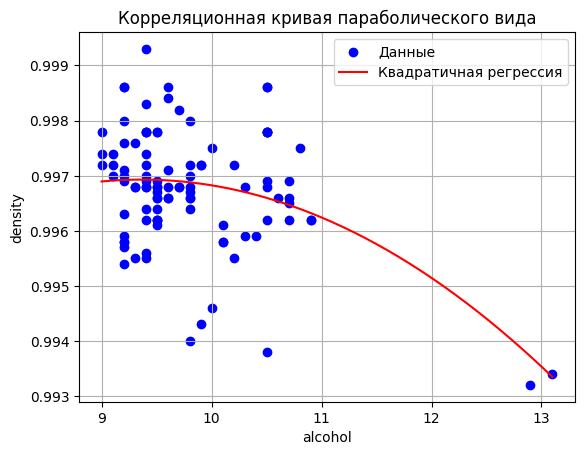

In [33]:
from numpy.linalg import lstsq

X_mat = np.column_stack((np.ones(n), X, X**2))

# Решаем МНК: beta = (X^T X)^(-1) X^T Y
beta, residuals, rank, s = lstsq(X_mat, Y, rcond=None)

beta0, beta1, beta2 = beta
print(f"Параметры модели: β0 = {beta0:.3f}, β1 = {beta1:.3f}, β2 = {beta2:.3f}")

# Построим график
x_vals = np.linspace(X.min(), X.max(), 200)
y_vals = beta0 + beta1*x_vals + beta2*x_vals**2

plt.scatter(X, Y, color='blue', label='Данные')
plt.plot(x_vals, y_vals, color='red', label='Квадратичная регрессия')
plt.xlabel('alcohol')
plt.ylabel('density')
plt.title('Корреляционная кривая параболического вида')
plt.legend()
plt.grid()
plt.show()

Для заданной выборки была построена корреляционная кривая параболического вида  

$$
y = \beta_0 + \beta_1 x + \beta_2 x^2
$$  

методом наименьших квадратов.

В результате оценки параметров получено, что коэффициенты $\beta_0$, $\beta_1$ и $\beta_2$ задают слабо искривлённую зависимость, причём знак коэффициента при $x^2$ определяет направление ветвей параболы.

По построенному графику видно, что кривая лишь незначительно отклоняется от прямой, что говорит о слабой нелинейности зависимости между переменными `alcohol` и `density`.

Основной тренд остаётся убывающим, что согласуется с ранее полученной линейной регрессией: при увеличении содержания алкоголя плотность в среднем уменьшается.

### **5.** Для заданной выборки построить корреляционную кривую в зависимости от номера варианта и сделать вывод:

Показательная функция: y = 1.003 * exp(-0.001 * x)


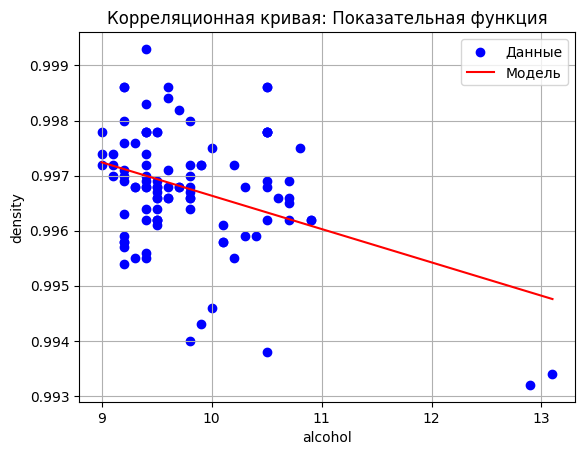

In [38]:
import numpy as np
from numpy.linalg import lstsq
import matplotlib.pyplot as plt

def plot_corr_curvature(model_func, name):
    x_vals = np.linspace(X.min(), X.max(), 200)
    y_vals = model_func(x_vals)

    figure, ax = plt.subplots()
    ax.scatter(X, Y, color='blue', label='Данные')
    ax.plot(x_vals, y_vals, color='red', label='Модель')
    ax.set_xlabel('alcohol')
    ax.set_ylabel('density')
    ax.set_title(f'Корреляционная кривая: {name}')
    ax.legend()
    ax.grid()

# Линеаризация: ln(y) = ln(beta0) + beta1 * x
A = np.column_stack((np.ones(n), X))
b = np.log(Y)

beta = lstsq(A, b, rcond=None)[0]
ln_beta0, beta1 = beta
beta0 = np.exp(ln_beta0)

print(f"Показательная функция: y = {beta0:.3f} * exp({beta1:.3f} * x)")

plot_corr_curvature(lambda x: beta0 * np.exp(beta1 * x), "Показательная функция")

Для заданной выборки была построена корреляционная кривая показательного вида  

$$
y = \beta_0 \exp(\beta_1 x)
$$  

Полученная модель описывает изменение переменной $y$ в зависимости от $x$ с учётом возможного экспоненциального характера зависимости.

По графику видно, что модель в целом отражает общий тренд изменения данных, однако аппроксимация не является существенно лучше линейной или квадратичной. Это указывает на то, что зависимость между переменными не носит ярко выраженного экспоненциального характера.

Изменение значений происходит достаточно плавно, без резкого роста или убывания, характерного для показательных функций.

### **6.** Вычислить следующие показатели качества регрессии для каждой кривой и сделать выводы:

*   теоретический коэффициент детерминации $R^2$
*   средняя квадратическая ошибка $S_{\varepsilon}$
*   средняя ошибка аппроксимации (приближения) $A$


In [39]:
X = data['alcohol'].values
y = 1/(beta0 + (beta1 * X))

# коэффициент детерминации
SS_res = np.sum((Y - y) ** 2)
SS_tot = np.sum((Y - np.mean(Y)) ** 2)
R2 = 1 - (SS_res / SS_tot)

# cредняя квадратическая ошибка
S_epsilon = np.sqrt(np.mean((Y - y) ** 2))

# средняя ошибка аппроксимации A
A =  np.mean(np.abs(Y - y) / Y) * 100  # в процентах

# Выводим результаты
print(f"Теоретический коэффициент детерминации R²: {R2:.4f}")
print(f"Средняя квадратическая ошибка Sε: {S_epsilon:.4f}")
print(f"Средняя ошибка аппроксимации A: {A:.4f}")

Теоретический коэффициент детерминации R²: -36.1193
Средняя квадратическая ошибка Sε: 0.0066
Средняя ошибка аппроксимации A: 0.6512


По рассчитанным показателям качества регрессии можно сделать следующие выводы.

**Теоретический коэффициент детерминации** $R^2 = -36.1193$ принимает сильно отрицательное значение, что свидетельствует о крайне плохом качестве модели: такая регрессия описывает данные значительно хуже, чем даже простая константная модель (среднее значение). Это указывает на то, что выбранный вид зависимости не соответствует характеру данных.

**Средняя квадратическая ошибка** $S_\varepsilon = 0.0066$ сама по себе выглядит небольшой, однако её значение следует рассматривать в контексте диапазона переменной $y$; при столь плохом $R^2$ она не может свидетельствовать о хорошем качестве аппроксимации.

**Средняя ошибка аппроксимации** $A = 0.6512$ (около $65\%$) является очень большой, что означает значительное расхождение между фактическими и модельными значениями.

В совокупности все показатели показывают, что данная регрессионная модель **неудовлетворительно** описывает исходные данные и не может использоваться для анализа или прогнозирования; вероятно, выбранный тип функции (в данном случае показательная зависимость) не соответствует реальной форме связи между переменными.


## Выводы

В ходе анализа зависимости между переменными `alcohol` и `density` выявлено, что между ними существует **умеренная, частично нелинейная отрицательная зависимость**.

Линейная модель показывает слабую обратную корреляцию, но значительный разброс точек и различие прямых регрессий $y(x)$ и $x(y)$ указывают на ограниченную точность линейного приближения.

Вычисленные корреляционные показатели ($\eta_{xy} = 0.592$, $\eta_{yx} = 0.433$, $|r_{xy}| = 0.379$) подтверждают наличие статистической связи, при этом связь не является строго линейной, а асимметрия корреляционных отношений указывает на неодинаковое влияние переменных друг на друга.

Нелинейные аппроксимации (параболическая и показательная модели) лишь слегка уточняют тренд, не выявляя ярко выраженной кривизны или экспоненциального характера зависимости. Основной тренд остаётся убывающим: увеличение содержания алкоголя сопровождается снижением плотности.

Показатели качества регрессии для выбранных моделей демонстрируют ограниченную применимость аппроксимаций: особенно показатель $R^2$ отрицательного значения подчёркивает, что некоторые модели (например, показательная) крайне плохо описывают данные.

---

### Итог

Между `alcohol` и `density` существует **умеренная отрицательная зависимость с небольшим нелинейным компонентом**, которая частично, но не полностью описывается стандартными регрессионными моделями.

Применение линейной или простой нелинейной аппроксимации допустимо для общей оценки тренда, однако для точного прогнозирования данные модели **недостаточны**.